# 서울시 부동산 시장조사 (2018~2024)
## 분석 목적
서울 부동산 시장의 전체적인 흐름을 파악하기 위한 탐색적 데이터 분석(EDA)

## 전처리 방침 — 이원화 근거
이 노트북은 **원본 데이터를 그대로 유지**합니다.
> 시장 전체 흐름(연도별 가격 추이, 거래량 변화)을 분석할 때는
> 이상치를 제거하면 실제 시장 충격(2021~2022년 급등기 등)이 왜곡되므로
> 극단값을 포함한 원본 데이터를 사용합니다.
>
> ※ 투자 성향별 분석(Z-score 비교)은 별도 노트북(서울시_부동산_투자분석.ipynb)에서
>    IQR 기반 이상치 제거 후 진행합니다.

## 데이터 구조
프로젝트 루트 기준으로 `data/` 폴더 안에 연도별 CSV 파일을 저장하세요.
```
프로젝트/
├── data/
│   ├── 2018.csv ~ 2024.csv
├── 서울시_부동산_시장조사.ipynb
└── 서울시_부동산_투자분석.ipynb
```


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Mac: AppleGothic / Windows: Malgun Gothic / Linux: NanumGothic)
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [10]:
# 데이터 로딩 (상대 경로 사용 → data/ 폴더에 CSV 저장 필요)
data_2018 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2018.csv', encoding="euc-kr",low_memory = False)
data_2019 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2019.csv', encoding="euc-kr",low_memory = False)
data_2020 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2020.csv', encoding="euc-kr",low_memory = False)
data_2021 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2021.csv', encoding="euc-kr",low_memory = False)
data_2022 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2022.csv', encoding="euc-kr",low_memory = False) 
data_2023 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2023.csv', encoding="euc-kr",low_memory = False)
data_2024 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2024.csv', encoding="euc-kr",low_memory = False)

In [ ]:
# 모든 데이터를 하나의 리스트로 만든 후 통합
# join="inner": 연도별 CSV의 컬럼이 다를 수 있으므로 공통 컬럼만 사용
dfs = [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
df_all = pd.concat(dfs, axis = 0, ignore_index = True, join = "inner")
print("통합 데이터 크기:", df_all.shape)

통합 데이터 크기: (833614, 21)


In [ ]:
# 거래 취소건 데이터에서 제거 → 실제 완료된 거래만 분석 대상
df_all = df_all[df_all["취소일"].isna()]
print("거래 취소 건 제거 후:", df_all.shape)

거래 취소 건 제거 후: (808073, 21)


In [13]:
# 건축연도 정제 → 불가능한 연도(1900 미만, 미래) 제거
df_all = df_all.copy()
df_all["건축년도"] = pd.to_numeric(df_all["건축년도"], errors="coerce")
current_year = pd.Timestamp.today().year
df_all = df_all[(df_all["건축년도"] >= 1900) & (df_all["건축년도"] <= current_year)]
print("건축연도 정제 후:", df_all.shape)

# ※ 이 노트북은 가격 이상치를 제거하지 않습니다.
# 시장 흐름 분석에서는 2021~2022년 급등기처럼 극단적 가격 변화가
# 중요한 인사이트이므로 원본 데이터를 유지합니다.

건축연도 정제 후: (797441, 21)


In [ ]:
# 건물면적(㎡) → 평수 변환 (1평 = 3.3㎡)
df_all["건물면적(㎡)"] = pd.to_numeric(df_all["건물면적(㎡)"], errors = "coerce")

# 평수 및 평당가격 구하기
# 평당가격 = 총 거래금액 / 평수 → 면적이 다른 물건 간 공정 비교 가능
df_all["평수"] = df_all["건물면적(㎡)"] / 3.3
df_all["평당가격"] = df_all["물건금액(만원)"] / df_all["평수"]

# 연도별 평균 평당 가격
avg_py_year = (df_all.groupby("접수연도")["평당가격"].mean().reset_index())
avg_py_year["평당가격"] = avg_py_year["평당가격"].round(2)
print(avg_py_year)

   접수연도     평당가격
0  2018  2371.04
1  2019  2793.40
2  2020  2923.07
3  2021  3176.23
4  2022  3115.02
5  2023  3726.05
6  2024  4126.40


## EDA (탐색적 데이터 분석)
전처리 이후 데이터의 기본 구조와 분포를 확인합니다.

In [21]:
# EDA: 데이터 기본 탐색
print("데이터 기본 정보")
print("-" * 55)
print(f"총 행 수: {len(df_all):,}")
print(f"총 컬럼 수: {len(df_all.columns)}")
print()

# 결측값 비율
null_rate = (df_all.isnull().sum() / len(df_all) * 100).round(2)
null_df = null_rate[null_rate > 0].sort_values(ascending=False)
print("결측값 비율 (있는 컬럼만):")
print(null_df.to_string())
print()

# 주요 수치 컬럼 요약 통계
print("주요 컬럼 기술 통계:")
print(df_all[["물건금액(만원)", "건물면적(㎡)", "평당가격"]].describe().round(1).to_string())

데이터 기본 정보
-------------------------------------------------------
총 행 수: 797,441
총 컬럼 수: 23

결측값 비율 (있는 컬럼만):
권리구분                100.00
취소일                 100.00
신고한 개업공인중개사 시군구명     78.40
신고구분                 73.51
토지면적(㎡)              20.27
지번구분                  6.81
지번구분명                 6.81
본번                    6.81
부번                    6.81
건물명                   6.81
층                     6.80

주요 컬럼 기술 통계:
         물건금액(만원)   건물면적(㎡)      평당가격
count    797441.0  797441.0  797441.0
mean      63555.8      69.9    3021.9
std       71607.0      64.9    1918.4
min        1700.0       5.1      78.8
25%       24500.0      38.9    1770.8
50%       41800.0      59.4    2546.8
75%       79120.0      84.8    3676.4
max    11087780.0    3619.8   32535.2


/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_87042/904091463.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years_list, patch_artist=True,


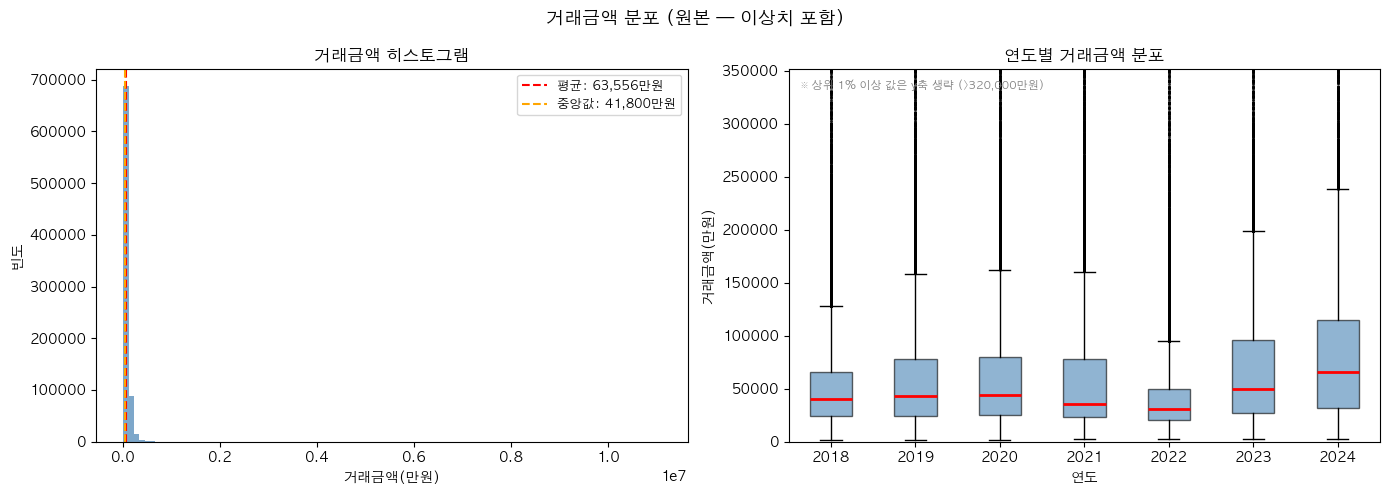

In [22]:
# EDA: 거래금액 분포 시각화 (원본 데이터)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("거래금액 분포 (원본 — 이상치 포함)", fontsize=13, fontweight="bold")

# 히스토그램
ax = axes[0]
ax.hist(df_all["물건금액(만원)"].dropna(), bins=100, color="steelblue", alpha=0.7, edgecolor="none")
ax.set_title("거래금액 히스토그램")
ax.set_xlabel("거래금액(만원)")
ax.set_ylabel("빈도")
ax.axvline(df_all["물건금액(만원)"].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"평균: {df_all['물건금액(만원)'].mean():,.0f}만원")
ax.axvline(df_all["물건금액(만원)"].median(), color="orange", linestyle="--",
           linewidth=1.5, label=f"중앙값: {df_all['물건금액(만원)'].median():,.0f}만원")
ax.legend(fontsize=9)

# 연도별 박스플롯
ax = axes[1]
years_list = sorted(df_all["접수연도"].unique())
data_by_year = [df_all[df_all["접수연도"] == y]["물건금액(만원)"].dropna() for y in years_list]
bp = ax.boxplot(data_by_year, labels=years_list, patch_artist=True,
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.set_title("연도별 거래금액 분포")
ax.set_xlabel("연도")
ax.set_ylabel("거래금액(만원)")
ax.tick_params(axis="x", rotation=0)

# 극단값으로 y축이 너무 크면 99퍼센타일로 제한
p99 = df_all["물건금액(만원)"].quantile(0.99)
ax.set_ylim(0, p99 * 1.1)
ax.text(0.02, 0.97, f"※ 상위 1% 이상 값은 y축 생략 (>{p99:,.0f}만원)", transform=ax.transAxes, fontsize=8, color="gray", va="top")

plt.tight_layout()
plt.show()

In [24]:
# EDA: 건물용도별 거래 현황
print("건물용도 분포:")
print(df_all["건물용도"].value_counts().to_string())
print()

# 건물용도별 평균 거래금액
bldg_price = (df_all.groupby("건물용도")["물건금액(만원)"].agg(["mean", "count"]).round(1).sort_values("mean", ascending=False))
bldg_price.columns = ["평균 거래금액(만원)", "거래 건수"]
print("건물용도별 평균 거래금액:")
print(bldg_price.to_string())

건물용도 분포:
건물용도
아파트      377445
연립다세대    282403
오피스텔      83341
단독다가구     54252

건물용도별 평균 거래금액:
       평균 거래금액(만원)   거래 건수
건물용도                      
단독다가구     125840.6   54252
아파트        87887.4  377445
연립다세대      30100.2  282403
오피스텔       26179.6   83341


## 서울 시장 연도별 추이 분석

In [18]:
# 서울 시장 분석에 필요한 값들 구하기

# 연도별 평균 매매가격
seoul_year_price = (df_all.groupby("접수연도")["물건금액(만원)"].mean().reset_index().sort_values("접수연도"))

# 연도별 평균 평당가격
seoul_year_py = (df_all.groupby("접수연도")["평당가격"].mean().reset_index().sort_values("접수연도"))

# 연도별 거래량
seoul_year_volume = (df_all.groupby("접수연도").size().reset_index(name="거래량").sort_values("접수연도"))

# 연도별 평당가격 상승률(%) → pct_change()로 전년 대비 상승률 계산
seoul_year_py_growth = seoul_year_py.copy()
seoul_year_py_growth["상승률(%)"] = seoul_year_py_growth["평당가격"].pct_change() * 100

# 서울 시장 요약 테이블
seoul_year_summary = (
    seoul_year_price[["접수연도", "물건금액(만원)"]]
    .merge(seoul_year_py[["접수연도", "평당가격"]], on="접수연도")
    .merge(seoul_year_volume, on="접수연도")
    .merge(seoul_year_py_growth[["접수연도", "상승률(%)"]], on="접수연도")
)
print(seoul_year_summary)

   접수연도      물건금액(만원)         평당가격     거래량     상승률(%)
0  2018  54441.506166  2371.036046  163733        NaN
1  2019  61659.764716  2793.398491  128428  17.813413
2  2020  62344.669249  2923.068353  174131   4.642011
3  2021  62772.538443  3176.232607  130922   8.660908
4  2022  54627.634961  3115.018766   61399  -1.927247
5  2023  75598.974759  3726.045659   65371  19.615512
6  2024  88197.941626  4126.399783   73457  10.744746


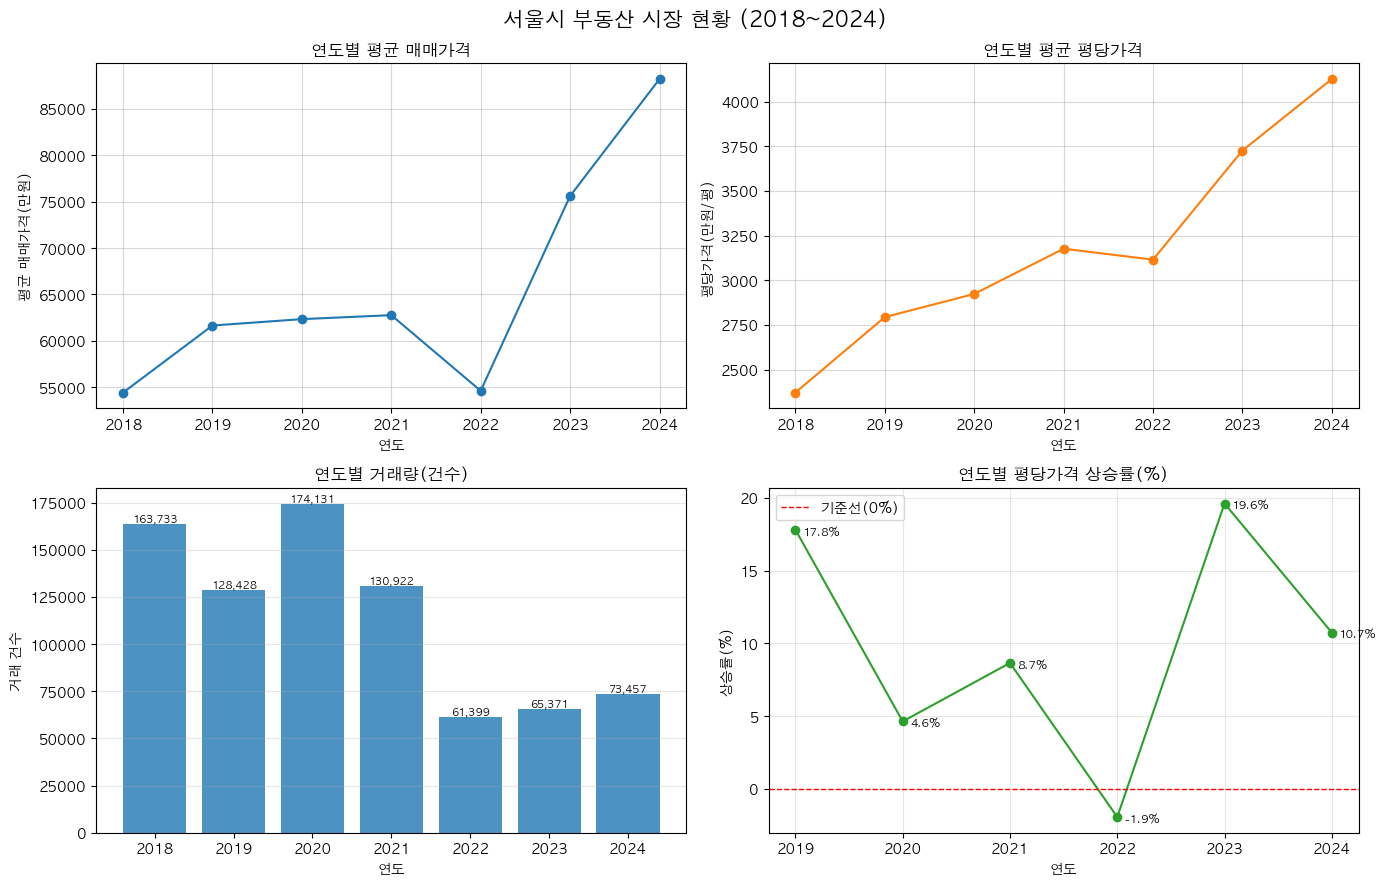

In [19]:
# 4개 지표를 한 figure에 통합해서 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("서울시 부동산 시장 현황 (2018~2024)", fontsize=15, fontweight="bold")

# 1. 연도별 평균 매매가격
ax = axes[0, 0]
ax.plot(seoul_year_summary["접수연도"], seoul_year_summary["물건금액(만원)"],
        marker="o", linestyle="-")
ax.set_title("연도별 평균 매매가격", fontsize=12)
ax.set_xlabel("연도")
ax.set_ylabel("평균 매매가격(만원)")
ax.grid(True, alpha=0.5)
ax.tick_params(axis="x", rotation=0)

# 2. 연도별 평균 평당가격
ax = axes[0, 1]
ax.plot(seoul_year_summary["접수연도"], seoul_year_summary["평당가격"],
        marker="o", linestyle="-", color="tab:orange")
ax.set_title("연도별 평균 평당가격", fontsize=12)
ax.set_xlabel("연도")
ax.set_ylabel("평당가격(만원/평)")
ax.grid(True, alpha=0.5)

# 3. 연도별 거래량(건수)
ax = axes[1, 0]
ax.bar(seoul_year_summary["접수연도"], seoul_year_summary["거래량"], alpha=0.8)
ax.set_title("연도별 거래량(건수)", fontsize=12)
ax.set_xlabel("연도")
ax.set_ylabel("거래 건수")
for i, v in enumerate(seoul_year_summary["거래량"]):
    ax.text(seoul_year_summary["접수연도"].iloc[i], v, f"{v:,}",
            ha="center", va="bottom", fontsize=7.5)
ax.grid(axis="y", alpha=0.3)

# 4. 연도별 평당가격 상승률(%)
ax = axes[1, 1]
ax.plot(seoul_year_summary["접수연도"], seoul_year_summary["상승률(%)"],
        marker="o", linestyle="-", color="tab:green")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="기준선(0%)")
ax.set_title("연도별 평당가격 상승률(%)", fontsize=12)
ax.set_xlabel("연도")
ax.set_ylabel("상승률(%)")
ax.grid(True, alpha=0.3)
ax.legend()
for i, v in enumerate(seoul_year_summary["상승률(%)"]):
    if pd.notna(v):
        ax.text(seoul_year_summary["접수연도"].iloc[i] + 0.07, v - 0.5,
                f"{v:.1f}%", ha="left", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()